In [1]:
import glob
import os
import numpy as np
import pandas as pd
from aeon.visualisation import plot_critical_difference, plot_pairwise_scatter
import matplotlib.pyplot as plt

# TSER

In [2]:
my_models = {
    "MultiRocket-TabPFN": 'tser/' + "results/Tab_multi.csv",
    "TsFresh-TabPFN": 'tser/' + "results/Tab_tsfresh.csv",
    "C22-TabPFN": 'tser/' + "results/Tab_c22.csv",
}
metric_name = "RMSE"

In [3]:
results = {}

for model_name, path in my_models.items():
    
    # Sempre ler com primeira coluna como índice
    df = pd.read_csv(path, index_col=0)

    # Garantir que índice é string
    df.index = df.index.astype(str)

    # Pegar apenas colunas numéricas (folds)
    df = df.select_dtypes(include="number")

    # Média por dataset
    mean_scores = df.mean(axis=1)

    results[model_name] = mean_scores

# Combinar
combined = pd.concat(results, axis=1)

# Remover datasets incompletos
combined = combined.dropna()

In [4]:
combined = pd.DataFrame(results)

# Remover datasets que não estejam presentes em todos
combined = combined.dropna()

print("Datasets usados:", len(combined))

Datasets usados: 55


<Figure size 1000x500 with 0 Axes>

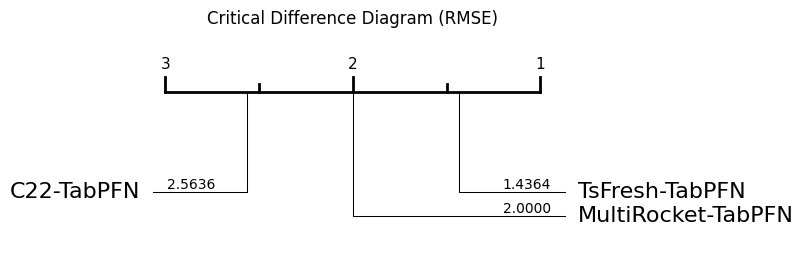

In [5]:
# converter para numpy
scores = combined.to_numpy()

# nomes dos modelos
labels = list(combined.columns)

plt.figure(figsize=(10, 5))

plot_critical_difference(
    scores,
    labels,
    lower_better=True  # RMSE → menor é melhor
)

plt.title(f"Critical Difference Diagram ({metric_name})")
plt.show()

In [6]:
model_files = {
    "TsFresh-TabPFN": 'tser/' + "results/Tab_tsfresh.csv",
    "MiniROCKET": 'tser/' + "results/MiniROCKET.csv",
    "DrCIF": 'tser/' + "results/DrCIF.csv",
    "FreshPRINCE": 'tser/' + "results/FreshPRINCE.csv",
    "InceptionT": 'tser/' + "results/InceptionT.csv",
    "MultiROCKET": 'tser/' + "results/MultiROCKET.csv",
    "RotF": 'tser/' + "results/RotF.csv",
    "TSF": 'tser/' + "results/TSF.csv",
    # "RandF": 'tser/' + "results/RandF.csv",
    # "ResNet": 'tser/' + "results/ResNet.csv",
    # "Ridge": 'tser/' + "results/Ridge.csv",
    # "ROCKET": 'tser/' + "results/ROCKET.csv",
    # "XGBoost": 'tser/' + "results/XGBoost.csv",
    # "CNN": 'tser/' + "results/CNN.csv",
}
lower_better = True

In [7]:
results = {}

for model_name, path in model_files.items():
    
    # Sempre ler com primeira coluna como índice
    df = pd.read_csv(path, index_col=0)

    # Garantir que índice é string
    df.index = df.index.astype(str)

    # Pegar apenas colunas numéricas (folds)
    df = df.select_dtypes(include="number")

    # Média por dataset
    mean_scores = df.mean(axis=1)

    results[model_name] = mean_scores

# Combinar
combined = pd.concat(results, axis=1)

# Remover datasets incompletos
combined = combined.dropna()

In [8]:
combined = pd.DataFrame(results)

# Remover datasets que não estejam presentes em todos
combined = combined.dropna()

print("Datasets usados:", len(combined))

Datasets usados: 55


<Figure size 1000x500 with 0 Axes>

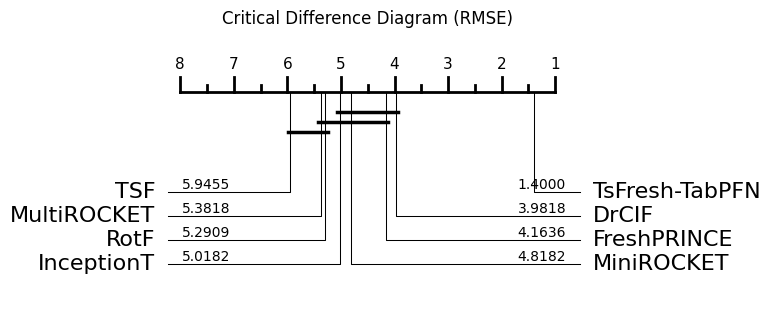

In [9]:
# converter para numpy
scores = combined.to_numpy()

# nomes dos modelos
labels = list(combined.columns)

plt.figure(figsize=(10, 5))

plot_critical_difference(
    scores,
    labels,
    lower_better=True  # RMSE → menor é melhor
)

plt.title(f"Critical Difference Diagram ({metric_name})")
plt.show()

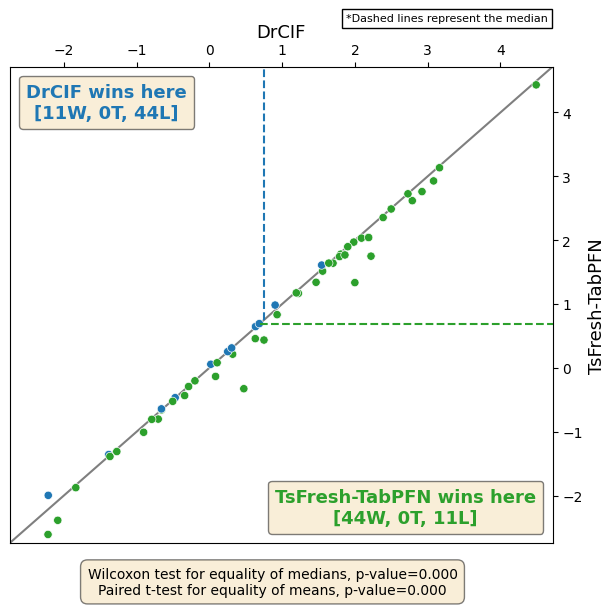

In [10]:
# 1. Carregar os DataFrames
df_tabpfn = pd.read_csv('tser/results/Tab_tsfresh.csv')
df_baseline = pd.read_csv('tser/results/DrCIF.csv')

# 2. Selecionar e renomear colunas
df_tabpfn = df_tabpfn.iloc[:, [0, 1]]
df_baseline = df_baseline.iloc[:, [0, 1]]
df_tabpfn.columns = ['dataset', 'res_tabpfn']
df_baseline.columns = ['dataset', 'res_baseline']

# 3. Alinhamento automático (Merge)
df_merged = pd.merge(df_tabpfn, df_baseline, on='dataset').dropna()

# 4. Extrair e aplicar Log10
# Usamos log10 para que os eixos representem ordens de magnitude (1, 10, 100...)
results_tabpfn_log = np.log10(df_merged['res_tabpfn'].values + 1e-6)
results_baseline_log = np.log10(df_merged['res_baseline'].values + 1e-6)

# 5. Gerar o gráfico
fig, ax = plot_pairwise_scatter(
    results_a=results_baseline_log, 
    results_b=results_tabpfn_log, 
    method_a="DrCIF", 
    method_b="TsFresh-TabPFN",
    metric="Log10(Error)", 
    lower_better=True,
    statistic_tests=True,
    best_on_top=True,
    figsize=(7, 7)
)

# Ajuste fino: melhorar os labels dos eixos para indicar que é escala log
ax.set_xlabel("DrCIF")
ax.set_ylabel("TsFresh-TabPFN")

fig.show()

# TSC

In [11]:
UNI_BASE = "/home/gcmerlin/exp/tabpfn-for-tsc-tser/tsc/results/Univariate"
MULTI_BASE = "/home/gcmerlin/exp/tabpfn-for-tsc-tser/tsc/results/Multivariate"

# Pegar arquivos
uni_files = glob.glob(UNI_BASE + "/*_accuracy.csv")
multi_files = glob.glob(MULTI_BASE + "/*_accuracy.csv")

def extract_model_name(path):
    return os.path.basename(path).replace("_accuracy.csv", "")

uni_models = {extract_model_name(f): f for f in uni_files}
multi_models = {extract_model_name(f): f for f in multi_files}

# Interseção
common_models = sorted(set(uni_models) & set(multi_models))

# --------------------------------------------------
# DICT FINAL (o que você quer)
# --------------------------------------------------

model_files = {
    model: [
        uni_models[model],
        multi_models[model],
    ]
    for model in common_models
}
model_files['C22-TabPFN'] = 'tsc/results/Tab_c22.csv'
model_files['TsFresh-TabPFN'] = 'tsc/results/Tab_tsfresh.csv'

metric_name = "accuracy"
lower_better = False

In [12]:
results = {}

for model_name, paths in model_files.items():

    # 🔒 Garantir que sempre seja lista
    if isinstance(paths, str):
        paths = [paths]

    model_series_list = []

    for path in paths:

        df = pd.read_csv(path, index_col=0)
        df.index = df.index.astype(str)
        df = df.select_dtypes(include="number")

        mean_scores = df.mean(axis=1)
        model_series_list.append(mean_scores)

    combined_model_scores = pd.concat(model_series_list)

    results[model_name] = combined_model_scores


combined = pd.concat(results, axis=1)
combined = combined.dropna()

In [13]:
combined = pd.DataFrame(results)

# Remover datasets que não estejam presentes em todos
combined = combined.dropna()

print("Datasets usados:", len(combined))

Datasets usados: 133


<Figure size 1000x500 with 0 Axes>

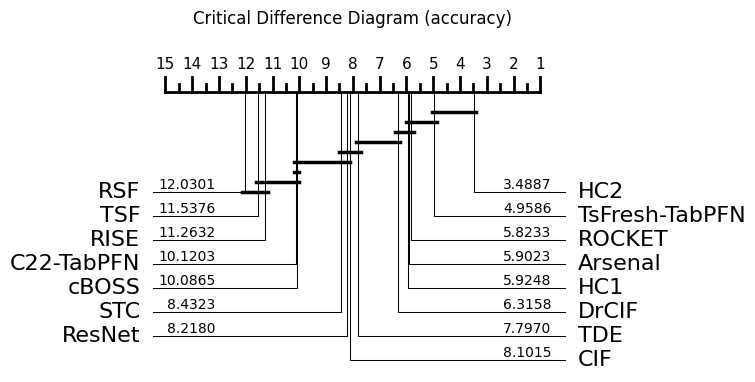

In [14]:
# converter para numpy
scores = combined.to_numpy()

# nomes dos modelos
labels = list(combined.columns)

plt.figure(figsize=(10, 5))

plot_critical_difference(
    scores,
    labels,
    lower_better=False
)

plt.title(f"Critical Difference Diagram ({metric_name})")
plt.show()